# Train1 Midterm to COVID-19 Twitter

Plots cross-dataset eval runs where the pretrained checkpoint came from `midterm` train1 and the target dataset is `covid19_twitter`.

In [39]:
import numpy as np
import pandas as pd
from sympy import limit
import wandb

api = wandb.Api(
    api_key="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"
)


In [40]:
# 1. Get last 10 runs (sorted by creation time descending)
runs = api.runs(
    "eibl-usc/graph-clip",
    filters={
        # "display_name": {"$regex": "trained_on_.._eval_on_.._..?_shot_.+"},
        # "config.dataset": "ukr_rus_twitter",
        # "config.task_name": "neighbor_matching",
    },
    order="-created_at",
    per_page=10,
    # limit to 10:
    lazy=False
)

rows = []
for run in runs[:250]:
    attrs = getattr(run, "_attrs", {}) or {}
    params = ((attrs.get("config") or {}).get("params") or {})
    # print(params)

    rows.append({
        "run_id": attrs.get("name"),
        "display_name": attrs.get("displayName"),
        "state": attrs.get("state"),
        "dataset": params.get("dataset"),
        "task_name": params.get("task_name"),
        "prefix": params.get("prefix"),
        "graph_filename": params.get("graph_filename"),
        "pretrained_model_run": params.get("pretrained_model_run"),
        "n_shots": params.get("n_shots"),
        "n_query": params.get("n_query"),
        "midterm_feature_subset": params.get("midterm_feature_subset"),
        "test_accuracy": (attrs.get("summaryMetrics") or {}).get("test_accuracy"),
        "test_f1": (attrs.get("summaryMetrics") or {}).get("test_f1"),
        "test_roc_auc": (attrs.get("summaryMetrics") or {}).get("test_roc_auc"),
    })

df = pd.DataFrame(rows)

In [82]:
EVAL_TASKS = ['nm', 'lp', 'pl']

In [79]:

# df = df[df["state"].eq("finished")].copy()
# df = df[df["dataset"].eq(TARGET_DATASET)].copy()
# df = df[df["pretrained_model_run"].fillna("").str.contains(TRAIN_PREFIX)].copy()

df["train1_dataset"] = df["pretrained_model_run"].str.extract(r"train1_(covid19_twitter|midterm|ukr_rus_twitter)_")
df["train1_task"] = df["pretrained_model_run"].str.extract(r"train1_.+?_(nm|pl|lp)_")
df["eval1_task"] = df["task_name"].map({
    "neighbor_matching": "nm",
    "temporal_link_prediction": "lp",
    "classification": "pl",
})
df["shot_label"] = df.apply(lambda r: 0 if bool(r.get("zero_shot", False)) else r["n_shots"], axis=1)
# plot_df = df[df["eval1_task"].isin(EVAL_TASKS) & df["train1_task"].eq("nm")].copy()
df['eval1_dataset'] = df['dataset']
i = df.train1_dataset.eq('midterm') & df.eval1_dataset.eq('covid19_twitter')
plot_df = df[i].copy()

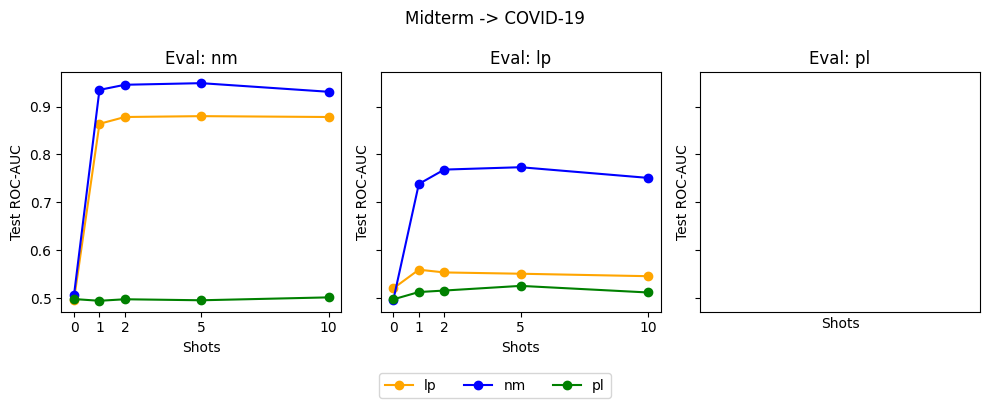

In [84]:
import matplotlib.pyplot as plt

# colors = {"nm": "tab:blue", "lp": "tab:orange", "pl": "tab:green"}
colors = {
    "nm": "blue",
    "lp": "orange",
    "pl": "green"
}

fig, axes = plt.subplots(1, len(EVAL_TASKS), figsize=(10, 4), sharey=True)
if len(EVAL_TASKS) == 1:
    axes = [axes]

for ax, eval_task in zip(axes, EVAL_TASKS):
    subset = plot_df[plot_df["eval1_task"] == eval_task]
    for train_task in sorted(subset["train1_task"].dropna().unique()):
        sub = subset[subset["train1_task"] == train_task].sort_values("shot_label")
        ax.plot(sub["shot_label"], sub["test_roc_auc"], marker="o", label=train_task, color=colors.get(train_task))
    ax.set_title(f"Eval: {eval_task}")
    ax.set_xlabel("Shots")
    ax.set_ylabel("Test ROC-AUC")
    ax.set_xticks(sorted(subset["shot_label"].dropna().unique()))

handles, labels = axes[0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc="lower center", ncol=max(1, len(labels)))

TITLE = "Midterm -> COVID-19"
fig.suptitle(TITLE)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()
